In [33]:
import os
path = "/content/drive/MyDrive/VTCA AI Specialist (HN03) /3. Datasets/AI Specialist 01 (Computer Vision)"
os.chdir(path)
os.listdir()

['Driving Plate.jpeg',
 'Human Face.jpeg',
 'Melanoma.jpeg',
 'Coconut.jpeg',
 'defect.jpeg',
 'Human Face 2.jpeg',
 'traffic sign.jpeg',
 'MultiFace01.jpeg',
 'MultiFace02.jpeg',
 'MultiFace03.jpeg']

In [2]:
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec

def ShowImage(ImageList, nRows = 1, nCols = 2, ImageTitleList = []):
    gs = gridspec.GridSpec(nRows, nCols)
    plt.figure(figsize=(20,20))
    for i in range(len(ImageList)):
        ax = plt.subplot(gs[i])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')

        plt.subplot(nRows, nCols,i+1)

        image = ImageList[i].copy()
        if (len(image.shape) < 3):
            plt.imshow(image, plt.cm.gray)
        else:
            plt.imshow(image)
        if(len(ImageTitleList)  > 0):
          plt.title("Image " + str(ImageTitleList[i]))
        else:
          plt.title("Image " + str(i))

        plt.axis('off')

    plt.show()

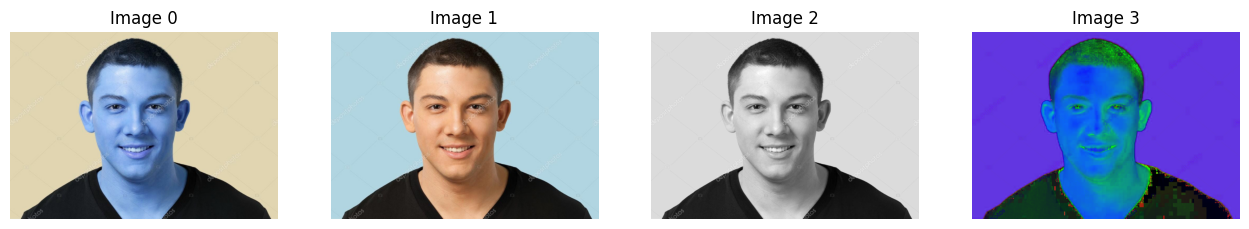

In [36]:
FileName = 'Human Face.jpeg'
image_orig = cv2.imread(FileName)
img = cv2.cvtColor(image_orig,cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_orig,cv2.COLOR_BGR2GRAY)
image_hsv = cv2.cvtColor(image_orig, cv2.COLOR_BGR2HSV)
ShowImage([image_orig, img, image_gray, image_hsv], 1, 5)

In [29]:
haar_cascade_frontalface = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
haar_cascade_profileface = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_profileface.xml')
haar_cascade_smile = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')
haar_cascade_lefteye = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_lefteye_2splits.xml')
haar_cascade_righteye = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_righteye_2splits.xml')
haar_cascade_eye =  cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

Faces found:  1


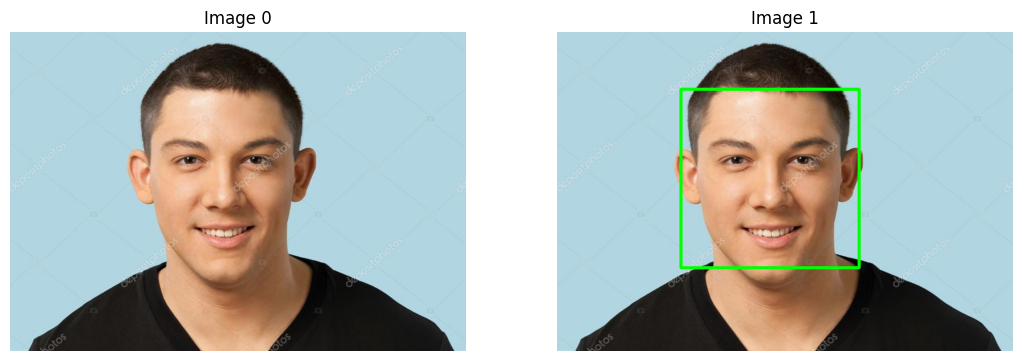

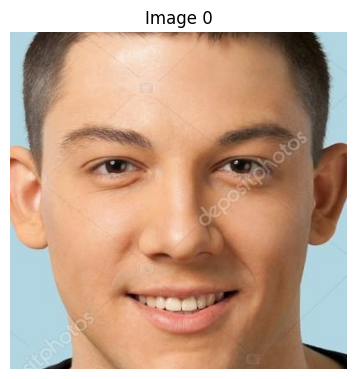

In [37]:
test_image = img.copy()
test_image_gray = image_gray.copy()

faces_rects = haar_cascade_frontalface.detectMultiScale(test_image_gray, scaleFactor = 1.2, minNeighbors = 5);

facelist_img = []
for (x,y,w,h) in faces_rects:
    if((x != 0) and (y != 0)):
        face_img = test_image[y:y+h, x:x+w].copy()
        facelist_img.append(face_img)
    cv2.rectangle(test_image, (x, y), (x+w, y+h), (0, 255, 0), 5)

# Let us print the no. of faces found
print('Faces found: ', len(facelist_img))
ShowImage([img, test_image], 1, 3)
ShowImage(facelist_img, 1, len(facelist_img) + 3)

Smiles found:  9


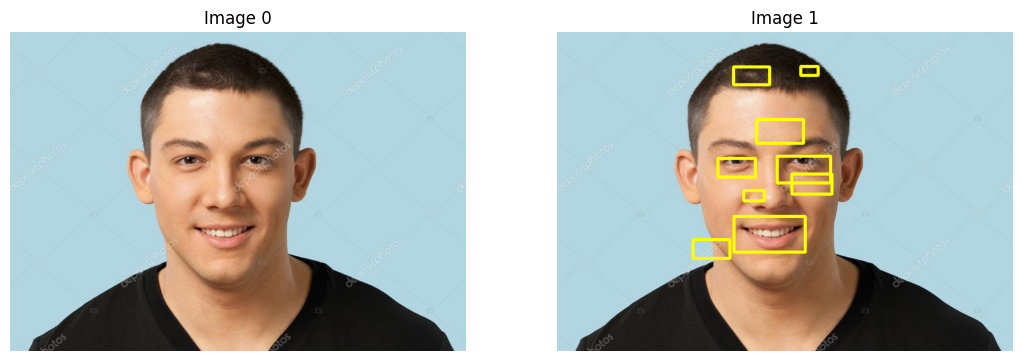

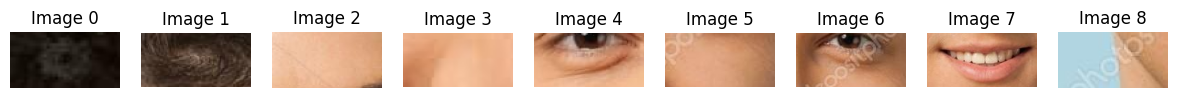

In [38]:
test_image = img.copy()
test_image_gray = image_gray.copy()

smile_rects = haar_cascade_smile.detectMultiScale(test_image_gray, scaleFactor = 1.2, minNeighbors = 5);

smilelist_img = []
for (x,y,w,h) in smile_rects:
    if((x != 0) and (y != 0)):
        smile_img = test_image[y:y+h, x:x+w].copy()
        smilelist_img.append(smile_img)

smile_showimg = test_image.copy()
for (x,y,w,h) in smile_rects:
     cv2.rectangle(smile_showimg, (x, y), (x+w, y+h), (255, 255, 0), 5)
# Let us print the no. of faces found
print('Smiles found: ', len(smilelist_img))
ShowImage([img, smile_showimg], 1, 3)
ShowImage(smilelist_img, 1, len(smilelist_img) + 3)

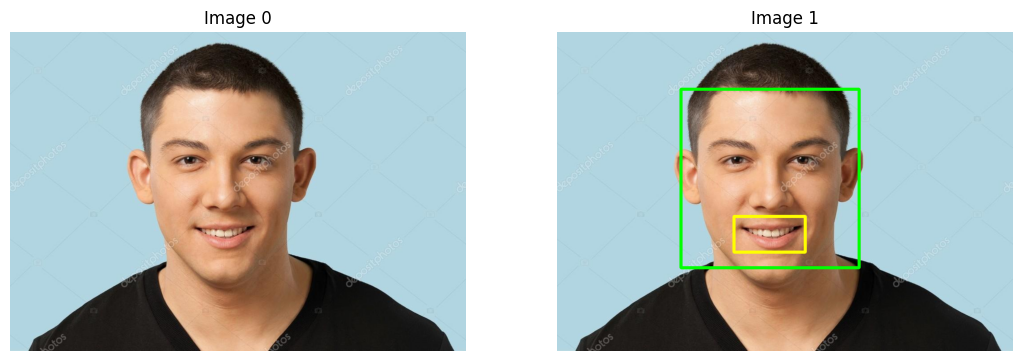

In [41]:
face_smile_image = test_image.copy()
for (x,y,w,h) in faces_rects:
    cv2.rectangle(face_smile_image, (x, y), (x+w, y+h), (0, 255, 0), 5)
    for (x_s,y_s,w_s,h_s) in smile_rects:
      if( (x <= x_s) and (y <= y_s) and ( x+w >= x_s+w_s) and ( y+h >= y_s+h_s) and (w_s/w > 0.35)):
          cv2.rectangle(face_smile_image, (x_s,y_s),(x_s+w_s,y_s+h_s),(255,255,0),5)

ShowImage([test_image, face_smile_image], 1, 3)

Eyes found:  4


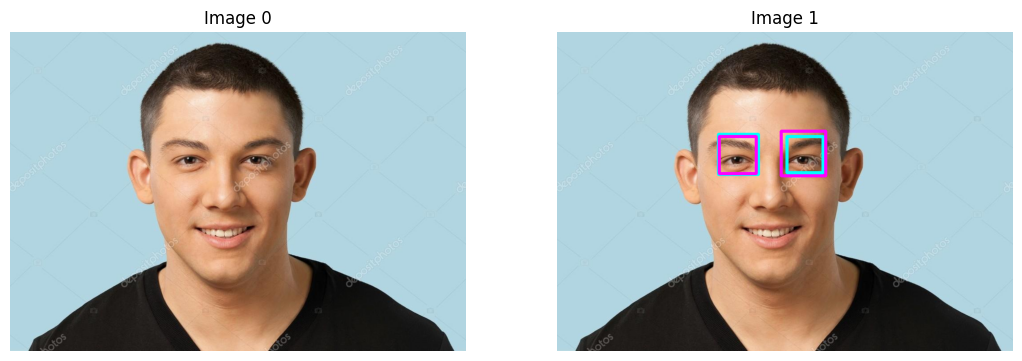

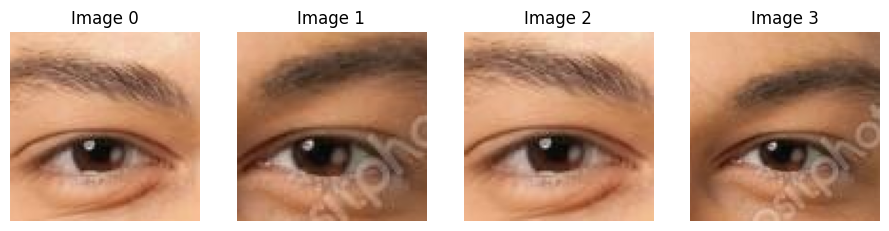

In [44]:
test_image = img.copy()
test_image_gray = image_gray.copy()

eye_rects1 = haar_cascade_lefteye.detectMultiScale(test_image_gray, scaleFactor = 1.2);
eye_rects2 = haar_cascade_righteye.detectMultiScale(test_image_gray, scaleFactor = 1.2);

eyelist_img = []
for (x,y,w,h) in eye_rects1:
    if((x != 0) and (y != 0)):
        eye_img = test_image[y:y+h, x:x+w].copy()
        eyelist_img.append(eye_img)

for (x,y,w,h) in eye_rects2:
    if((x != 0) and (y != 0)):
        eye_img = test_image[y:y+h, x:x+w].copy()
        eyelist_img.append(eye_img)

eye_showimg = test_image.copy()
for (x,y,w,h) in eye_rects1:
     cv2.rectangle(eye_showimg, (x, y), (x+w, y+h), (0, 255, 255), 5)

for (x,y,w,h) in eye_rects2:
     cv2.rectangle(eye_showimg, (x, y), (x+w, y+h), (255, 0, 255), 5)

# Let us print the no. of faces found
print('Eyes found: ', len(eyelist_img))
ShowImage([test_image, eye_showimg], 1, 3)
ShowImage(eyelist_img, 1, len(eyelist_img) + 3)

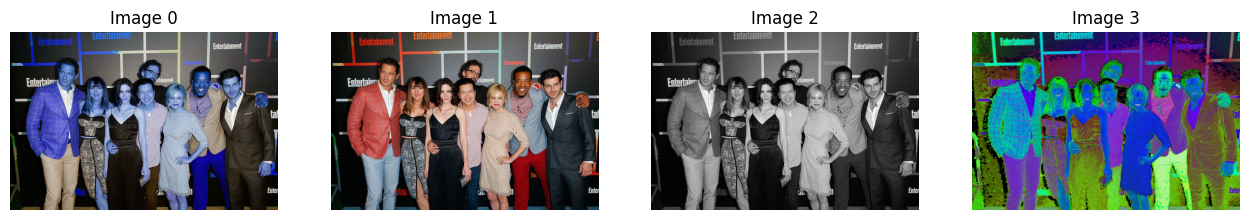

In [34]:
FileName = 'MultiFace01.jpeg'
image_orig = cv2.imread(FileName)
img = cv2.cvtColor(image_orig,cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_orig,cv2.COLOR_BGR2GRAY)
image_hsv = cv2.cvtColor(image_orig, cv2.COLOR_BGR2HSV)
ShowImage([image_orig, img, image_gray, image_hsv], 1, 5)

Faces found:  8


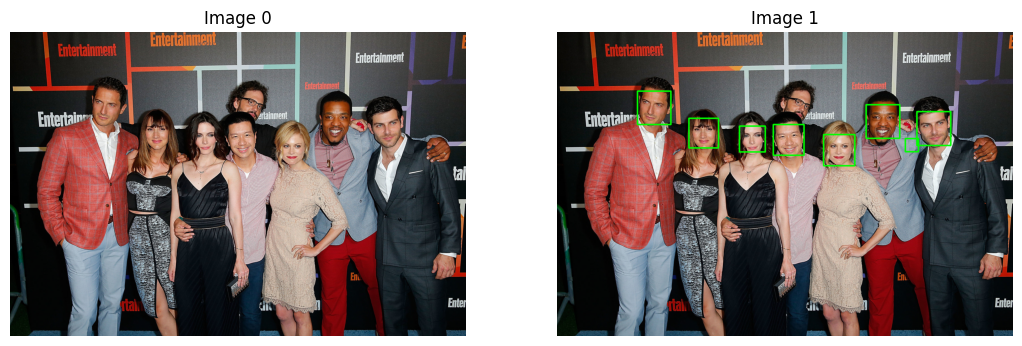

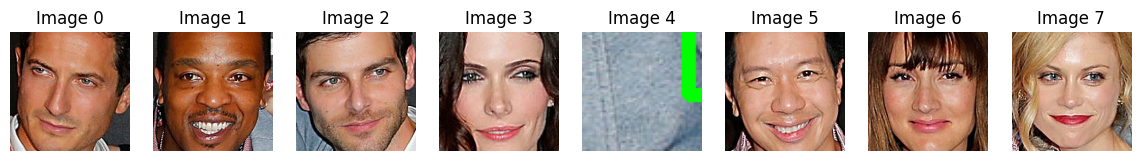

In [35]:
test_image = img.copy()
test_image_gray = image_gray.copy()

faces_rects = haar_cascade_frontalface.detectMultiScale(test_image_gray, scaleFactor = 1.2, minNeighbors = 5);

facelist_img = []
for (x,y,w,h) in faces_rects:
    if((x != 0) and (y != 0)):
        face_img = test_image[y:y+h, x:x+w].copy()
        facelist_img.append(face_img)
    cv2.rectangle(test_image, (x, y), (x+w, y+h), (0, 255, 0), 5)

# Let us print the no. of faces found
print('Faces found: ', len(facelist_img))
ShowImage([img, test_image], 1, 3)
ShowImage(facelist_img, 1, len(facelist_img) + 3)

In [46]:
from pylab import imread
image = imread('Melanoma.jpeg')
print(image.shape)

(1125, 1500, 3)


In [47]:
from skimage.transform import rescale, resize
import cv2

OrigWidth, OrigHeight = float(image.shape[1]), float(image.shape[0])

wresize = 300
hresize = int((OrigHeight * wresize)/OrigWidth)
image = cv2.resize(image, (wresize, hresize), interpolation = cv2.INTER_NEAREST)
print(image.shape)

(225, 300, 3)


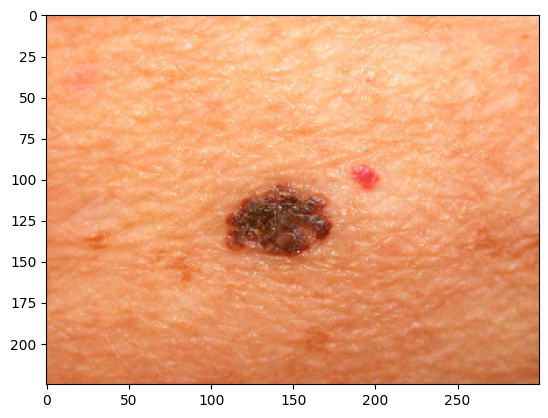

In [48]:
from matplotlib import pyplot as plt
plt.imshow(image)

In [56]:
from skimage.feature import hog
from skimage import exposure

HoGfeature, hog_image = hog(image, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), visualize=True,
                feature_vector = True,
                channel_axis=-1)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
print(HoGfeature)

[0.154159   0.05094166 0.07239378 ... 0.04465533 0.10962599 0.08530414]


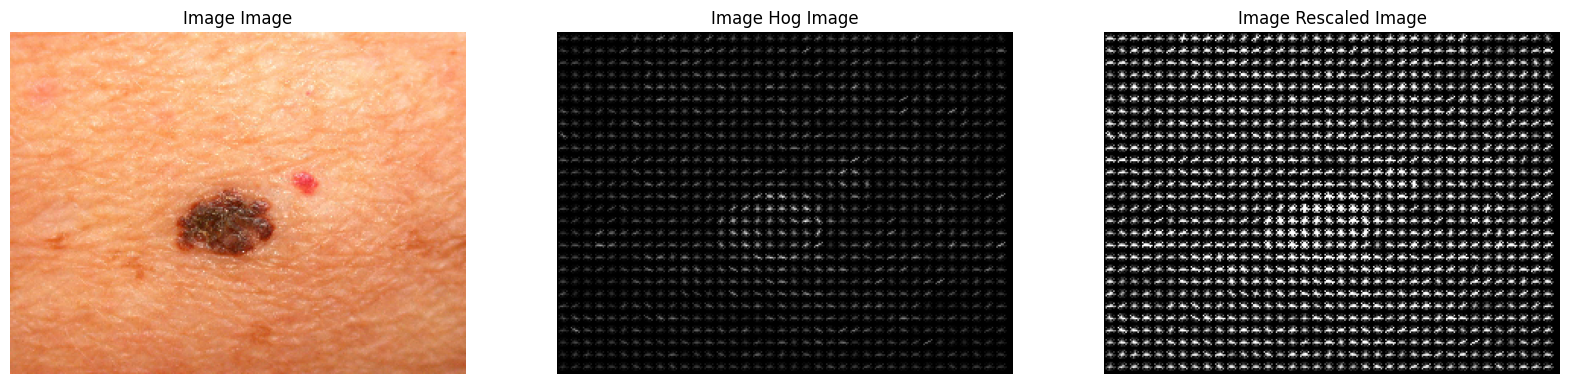

In [50]:
ShowImage([image, hog_image, hog_image_rescaled], 1, 3, ["Image", "Hog Image", "Rescaled Image"])

In [61]:
def CalHogFeature(imagepath):
  image = imread(imagepath)
  print(image.shape)

  OrigWidth, OrigHeight = float(image.shape[1]), float(image.shape[0])
  wresize = 300
  hresize = 200
  # hresize = int((OrigHeight * wresize)/OrigWidth)
  image = cv2.resize(image, (wresize, hresize), interpolation = cv2.INTER_NEAREST)
  print(image.shape)

  HoGfeature, hog_image = hog(image, orientations=9, pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2), visualize=True,
                  feature_vector = True,
                  channel_axis=-1)
  hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
  print(HoGfeature)
  print(len(HoGfeature))
  return HoGfeature, hog_image, hog_image_rescaled

In [62]:
HoGfeature1, hog_image1, hog_image_rescaled1 = CalHogFeature("Melanoma.jpeg")
HoGfeature2, hog_image2, hog_image_rescaled2 = CalHogFeature("Human Face.jpeg")
HoGfeature3, hog_image3, hog_image_rescaled3 = CalHogFeature("Human Face 2.jpeg")

(1125, 1500, 3)
(200, 300, 3)
[0.14656417 0.06979345 0.07773459 ... 0.12112494 0.04884314 0.06979007]
31104
(717, 1024, 3)
(200, 300, 3)
[0.         0.         0.         ... 0.40451813 0.40451813 0.35649293]
31104
(667, 1000, 3)
(200, 300, 3)
[0.28045153 0.08637189 0.26506919 ... 0.0604463  0.02692597 0.        ]
31104


31104
31104
31104


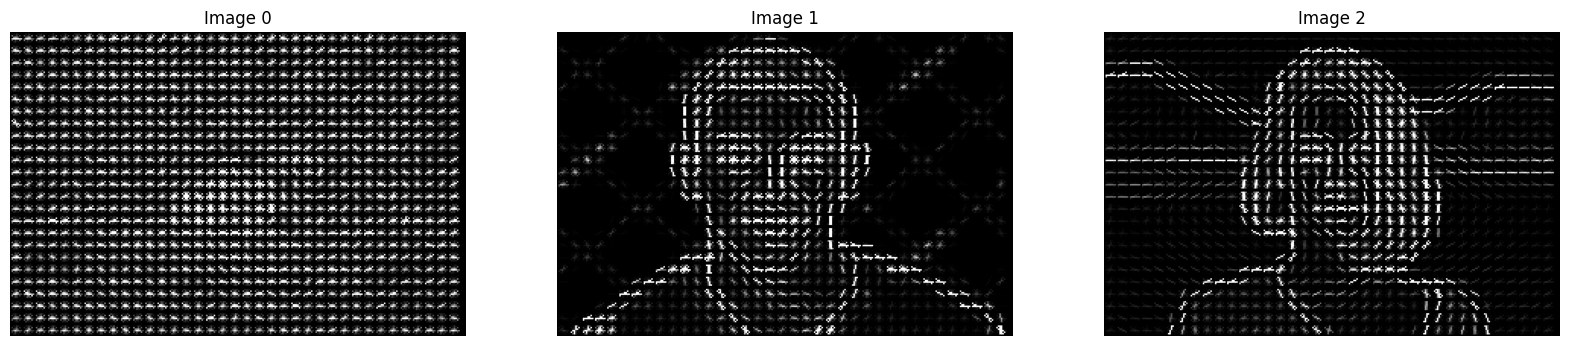

In [63]:
print(len(HoGfeature1))
print(len(HoGfeature2))
print(len(HoGfeature3))

ShowImage([hog_image_rescaled1, hog_image_rescaled2, hog_image_rescaled3], 1, 3)

In [66]:
# dist12 = np.linalg.norm(HoGfeature1-HoGfeature2)
# print(dist12)

# dist13 = np.linalg.norm(HoGfeature1-HoGfeature3)
# print(dist13)

# dist23 = np.linalg.norm(HoGfeature2-HoGfeature3)
# print(dist23)

26.83359484739075
24.43389998603505
30.111111998104413


In [72]:
import numpy as np
from numpy.linalg import norm

A = HoGfeature1
B = HoGfeature2
cosine12 = np.dot(A,B)/(norm(A)*norm(B))
print(cosine12)

A = HoGfeature1
B = HoGfeature3
cosine13 = np.dot(A,B)/(norm(A)*norm(B))
print(cosine13)

A = HoGfeature2
B = HoGfeature3
cosine23 = np.dot(A,B)/(norm(A)*norm(B))
print(cosine23)

0.5672092605202809
0.6545049371103818
0.4548238277630959


In [18]:
from skimage.feature import corner_harris, corner_peaks

def DetectHarisCorner(image, image_value):
  coords = corner_peaks(corner_harris(image_value), min_distance=8, threshold_rel=0.01)

  coordsList = []
  for x_idx, y_idx in coords:
    coordsList.append((x_idx, y_idx))

  image_demo = image.copy()
  for x_idx, y_idx in coordsList:
    cv2.drawMarker(image_demo, (y_idx, x_idx),(0,255,255),
                  markerType=cv2.MARKER_STAR, markerSize=7, thickness=1, line_type=cv2.LINE_AA)

  return image_demo, coordsList

In [19]:
os.listdir()

['Driving Plate.jpeg',
 'Human Face.jpeg',
 'Melanoma.jpeg',
 'Coconut.jpeg',
 'defect.jpeg',
 'Human Face 2.jpeg',
 'traffic sign.jpeg']

(750, 1000, 3)
(225, 300, 3)
[(209, 97), (214, 83), (129, 117), (140, 105), (120, 119), (111, 100), (96, 169), (126, 103), (99, 159), (199, 109), (185, 117), (194, 83), (132, 56), (99, 123), (166, 84), (154, 76), (75, 188), (167, 135), (189, 92), (114, 187), (148, 150), (84, 45), (88, 100), (107, 196), (107, 28), (102, 146), (101, 133), (104, 184), (84, 142), (82, 200), (138, 161), (115, 38), (97, 202), (85, 123), (58, 124), (55, 104), (57, 158), (64, 169), (38, 128), (51, 147), (36, 109), (58, 84), (35, 119), (65, 74), (138, 171)]


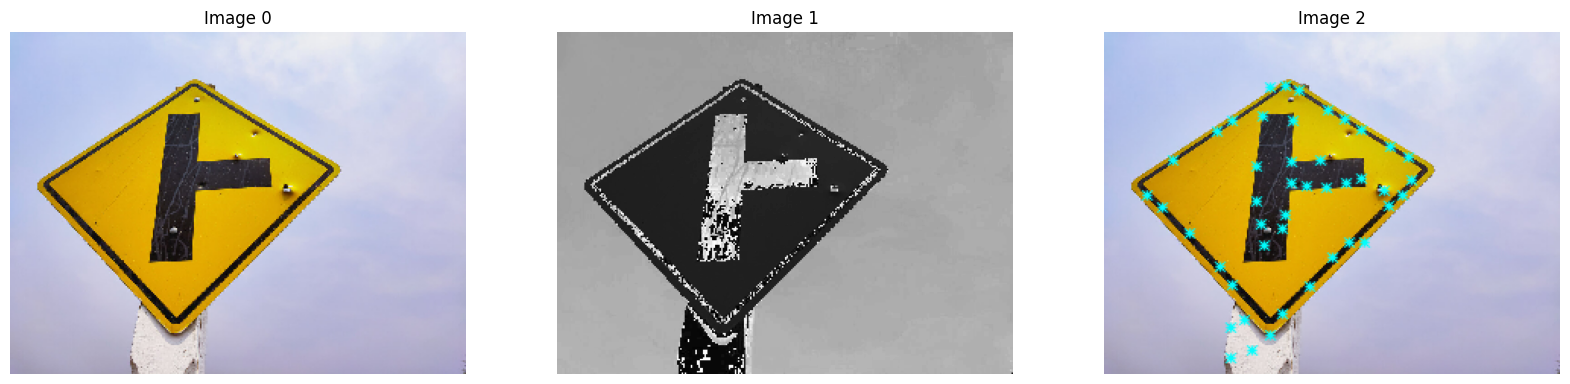

In [20]:
image = imread('traffic sign.jpeg')
print(image.shape)
OrigWidth, OrigHeight = float(image.shape[1]), float(image.shape[0])
wresize = 300
hresize = int((OrigHeight * wresize)/OrigWidth)
image = cv2.resize(image, (wresize, hresize), interpolation = cv2.INTER_NEAREST)
print(image.shape)

image_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
image_value = image_hsv[:,:,0]
image_demo, coordsList = DetectHarisCorner(image, image_value)

print(coordsList)
ShowImage([image, image_value, image_demo], 1, 3)

In [21]:
from skimage.feature import match_descriptors, plot_matches, ORB

def DetectORBKeypoints(image, image_value, NumKeypoints = 50):
  descriptor_extractor = ORB(n_keypoints = NumKeypoints)
  descriptor_extractor.detect_and_extract(image_value)
  keypoints = descriptor_extractor.keypoints

  KeyPointsList = []
  for x_idx, y_idx in keypoints:
    KeyPointsList.append((int(x_idx), int(y_idx)))

  image_demo = image.copy()
  for x_idx, y_idx in KeyPointsList:
    cv2.drawMarker(image_demo, (y_idx, x_idx),(0,255,255),
                markerType=cv2.MARKER_STAR, markerSize=7, thickness=1, line_type=cv2.LINE_AA)

  return image_demo, KeyPointsList

In [22]:
os.listdir()

['Driving Plate.jpeg',
 'Human Face.jpeg',
 'Melanoma.jpeg',
 'Coconut.jpeg',
 'defect.jpeg',
 'Human Face 2.jpeg',
 'traffic sign.jpeg']

(500, 780, 3)
(192, 300, 3)
[(26, 67), (25, 75), (146, 162), (146, 147), (162, 242), (142, 143), (74, 250), (147, 159), (25, 74), (146, 151), (150, 97), (25, 67), (25, 79), (147, 135), (136, 197), (148, 164), (146, 172), (145, 187), (162, 242), (136, 117), (135, 165), (91, 166), (91, 135), (148, 179), (148, 97), (161, 57), (137, 113), (148, 151), (148, 161), (22, 235), (136, 186), (150, 106), (135, 172), (145, 151), (136, 159), (113, 74), (147, 195), (21, 74), (101, 153), (72, 193), (149, 97), (160, 56), (143, 22), (141, 198), (137, 162), (162, 243), (148, 138), (74, 216), (142, 153), (150, 98), (148, 132), (142, 148), (75, 41), (167, 40), (101, 147), (141, 135), (134, 186), (142, 153), (161, 56), (142, 114), (142, 142), (153, 50), (145, 197), (87, 30), (143, 150), (147, 112), (158, 52), (100, 152), (72, 139), (149, 203), (148, 201), (148, 186), (148, 199), (135, 121), (134, 152), (141, 159), (149, 99), (137, 151), (143, 188), (148, 169), (135, 136), (130, 97), (148, 125), (147, 122), 

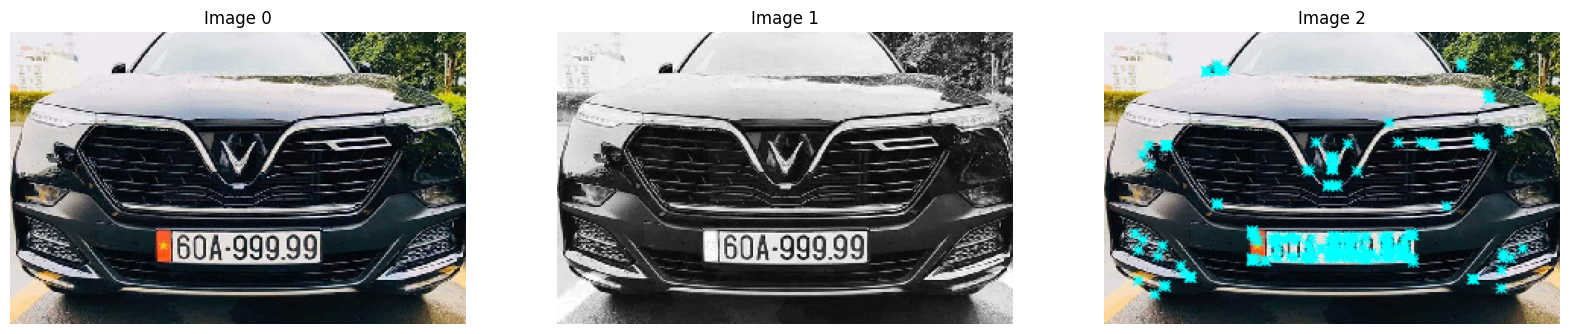

In [23]:
image = imread('Driving Plate.jpeg')
print(image.shape)
OrigWidth, OrigHeight = float(image.shape[1]), float(image.shape[0])
wresize = 300
hresize = int((OrigHeight * wresize)/OrigWidth)
image = cv2.resize(image, (wresize, hresize), interpolation = cv2.INTER_NEAREST)
print(image.shape)

image_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
image_value = image_hsv[:,:,2]
# image_demo, coordsList = DetectHarisCorner(image, image_value)
image_demo, KeyPointsList = DetectORBKeypoints(image, image_value, NumKeypoints = 200)

print(KeyPointsList)
ShowImage([image, image_value, image_demo], 1, 3)

In [ ]:
# ORB points ==> Kmeans ==> Group with largest number of points
# ==> left, right, top, bottom of points ==> bounding box

In [24]:
import numpy as np
def DFT_Transformation(image, image_value, display = 1):
    img_float32 = np.float32(image_value)
    dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

    if(display):
      ShowImage([image, image_value, magnitude_spectrum], 1, 5, ImageTitleList= ["Origin", "Gray Image", "Magnitude Spectrum"])
    return magnitude_spectrum, dft_shift

In [ ]:
os.listdir()

['Driving Plate.jpeg',
 'Human Face.jpeg',
 'Melanoma.jpeg',
 'Coconut.jpeg',
 'defect.jpeg',
 'Human Face 2.jpeg',
 'traffic sign.jpeg']

(750, 1000, 3)
(225, 300, 3)


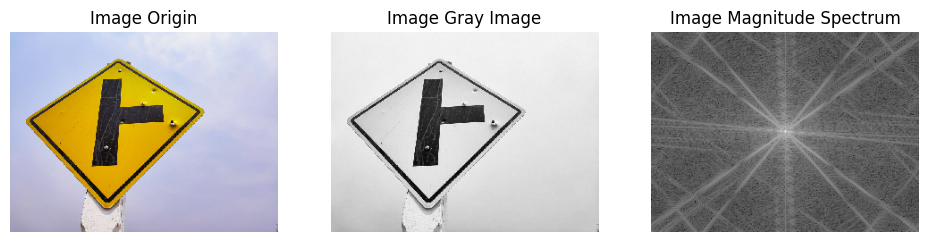

In [25]:
image = imread('traffic sign.jpeg')
print(image.shape)
OrigWidth, OrigHeight = float(image.shape[1]), float(image.shape[0])
wresize = 300
hresize = int((OrigHeight * wresize)/OrigWidth)
image = cv2.resize(image, (wresize, hresize), interpolation = cv2.INTER_NEAREST)
print(image.shape)

image_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
image_value = image_hsv[:,:,2]

magnitude_spectrum, dft_shift = DFT_Transformation(image, image_value, display = 1)

In [26]:
def DFT_Seperation(image, magnitude_spectrum, dft_shift , maskSize = 50, display = 1):
  rows, cols = magnitude_spectrum.shape
  crow,ccol = (int)(rows/2) , (int)(cols/2)
  size = maskSize

  # FOR LOW FREQUENCY
  # create a mask first, center square is 1, remaining all zeros
  mask_LowFeq = np.zeros((rows, cols, 2), np.uint8)
  mask_LowFeq[crow-size:crow+size, ccol-size:ccol+size] = 1
  # apply mask and inverse DFT
  magnitude_spectrum_crop_LowFeq = magnitude_spectrum* mask_LowFeq[:,:,0]
  fshift_LowFeq = dft_shift*mask_LowFeq
  f_ishift_LowFeq = np.fft.ifftshift(fshift_LowFeq)
  img_inverse_LowFeq = cv2.idft(f_ishift_LowFeq)
  image_inverse_LowFeq = cv2.magnitude(img_inverse_LowFeq[:,:,0],img_inverse_LowFeq[:,:,1])

  # FOR LOW FREQUENCY
  # create a mask first, center square is 1, remaining all zeros
  mask_HiFeq = 1 - mask_LowFeq
  # apply mask and inverse DFT
  magnitude_spectrum_crop_HiFeq = magnitude_spectrum* mask_HiFeq[:,:,0]
  fshift_HiFeq = dft_shift*mask_HiFeq
  f_ishift_HiFeq = np.fft.ifftshift(fshift_HiFeq)
  img_inverse_HiFeq = cv2.idft(f_ishift_HiFeq)
  image_inverse_HiFeq = cv2.magnitude(img_inverse_HiFeq[:,:,0],img_inverse_HiFeq[:,:,1])

  if(display):
    ImageTitleList = ["Origin", "Spectrum", "Mask", "Cropped Spectrum", "Low Frequency"]
    ShowImage([image, magnitude_spectrum, mask_LowFeq[:,:,0], magnitude_spectrum_crop_LowFeq, image_inverse_LowFeq], 1, 5, ImageTitleList)
    ImageTitleList = ["Origin", "Spectrum", "Mask", "Cropped Spectrum", "High Frequency"]
    ShowImage([image, magnitude_spectrum, mask_HiFeq[:,:,0], magnitude_spectrum_crop_HiFeq, image_inverse_HiFeq], 1, 5, ImageTitleList)

  return image_inverse_LowFeq, image_inverse_HiFeq

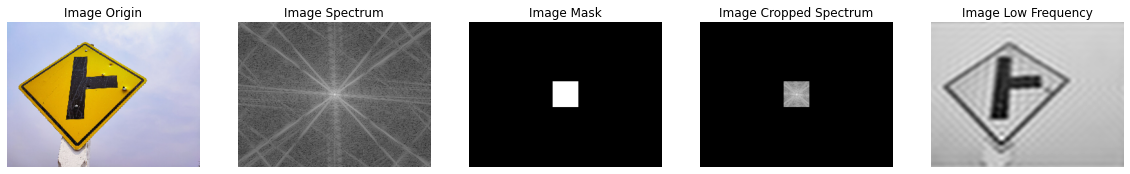

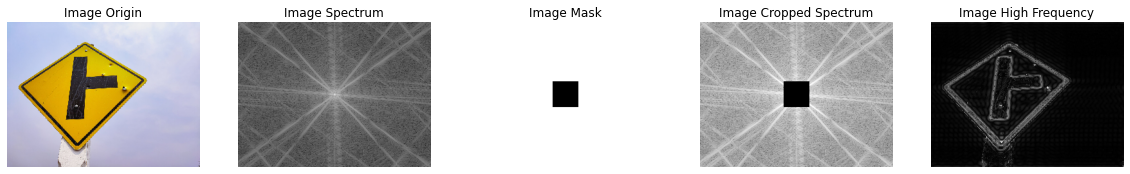

In [ ]:
image_inverse_LowFeq, image_inverse_HiFeq = DFT_Seperation(image, magnitude_spectrum, dft_shift , maskSize = 20, display = 1)